In [21]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import time
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import string
import numpy as np
import tensorflow as tf
from keras.layers import (
    Dense,
    Convolution2D,
    MaxPooling2D,
    Flatten,
)
from keras.models import Sequential
from PIL import Image, ImageOps
import matplotlib.pyplot as plt


In [8]:
RUSSIAN_WEIGHTS = "api/weights/comnist_keras_ru.hdf5"
TEST_DIR = "images/Cyrillic_test"
SIZE = 32
nb_classes = 34
batch_size = 32
img_height = 32
img_width = 32



In [9]:
# Load the datasets


# test_dataset = tf.keras.utils.image_dataset_from_directory(
#     TEST_DIR,
#     seed=123,
#     image_size=(img_height, img_width),
#     batch_size=batch_size,
#     labels="inferred",
# )

class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
name_to_index = {name: i for i, name in enumerate(class_names)}
print(class_names)
print(name_to_index)

['I', 'Ё', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']
{'I': 0, 'Ё': 1, 'А': 2, 'Б': 3, 'В': 4, 'Г': 5, 'Д': 6, 'Е': 7, 'Ж': 8, 'З': 9, 'И': 10, 'Й': 11, 'К': 12, 'Л': 13, 'М': 14, 'Н': 15, 'О': 16, 'П': 17, 'Р': 18, 'С': 19, 'Т': 20, 'У': 21, 'Ф': 22, 'Х': 23, 'Ц': 24, 'Ч': 25, 'Ш': 26, 'Щ': 27, 'Ъ': 28, 'Ы': 29, 'Ь': 30, 'Э': 31, 'Ю': 32, 'Я': 33}


Loaded weights from file api/weights/comnist_keras_ru.hdf5
Created model and loaded weights from file


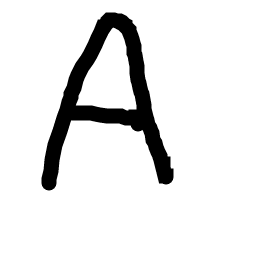

In [10]:
from api.model import load_letter_predictor
from IPython.display import display


commnist_predictor = load_letter_predictor(weight=RUSSIAN_WEIGHTS, nb_classes=34, lang_in="ru")
img_copy = Image.open("images/Cyrillic_test/А/5a2f3c19c27bb.png")
blank = Image.new("L", img_copy.size, color=255)
img_copy.paste(blank, (0, 0), mask=img_copy)
img_copy = img_copy.convert("L")
img_copy = ImageOps.invert(img_copy)
display(img_copy)


In [11]:
from api.image_proc import crop_letters


for i, letter in enumerate(crop_letters(img_copy)):
    predicted_letter = commnist_predictor(letter,1)
    print(f"Predicted letter: {predicted_letter}")

Predicted letter: ['А']


In [12]:
y_true = []
y_pred = []

for cls in class_names:
    folder = os.path.join(TEST_DIR, cls)
    for fn in os.listdir(folder):
        img_path = os.path.join(folder, fn)
        img = Image.open(img_path)

            # Add a white background to the image

        blank = Image.new("L", img.size, color=255)
        img.paste(blank, (0, 0), mask=img)
        img = img.convert("L")
        img = ImageOps.invert(img)

        # Get negative of image in case it is white on black
        # img_np = np.array(img)
        # if np.mean(img_np) < 128:
            
            
            
        pred_list = commnist_predictor(img, nb_output=1)   # returns list like ['Д']
        pred_char = pred_list[-1]
        # convert true/pred to integer class indices
        y_true.append(name_to_index[cls])
        # find predicted class index in class_names (ensure char == folder name)
        # if your folder names are letter characters use:
        y_pred.append(name_to_index.get(pred_char, -1))



In [16]:


print("Accuracy:", accuracy_score(y_true, y_pred)*100,"%")

Accuracy: 90.15232782664664 %


In [17]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           I       1.00      1.00      1.00        75
           Ё       0.55      0.98      0.71       104
           А       0.98      0.87      0.92       141
           Б       0.89      0.94      0.91       134
           В       0.98      0.84      0.91       147
           Г       0.89      0.98      0.93       128
           Д       0.92      0.83      0.87       140
           Е       0.84      0.62      0.71       173
           Ж       0.96      0.98      0.97       139
           З       0.94      0.69      0.80       130
           И       1.00      0.73      0.84       135
           Й       0.85      1.00      0.92       140
           К       0.99      0.89      0.94       138
           Л       0.98      0.99      0.98       130
           М       0.97      0.96      0.96       141
           Н       0.97      0.97      0.97       153
           О       1.00      0.92      0.96       140
           П       0.92    

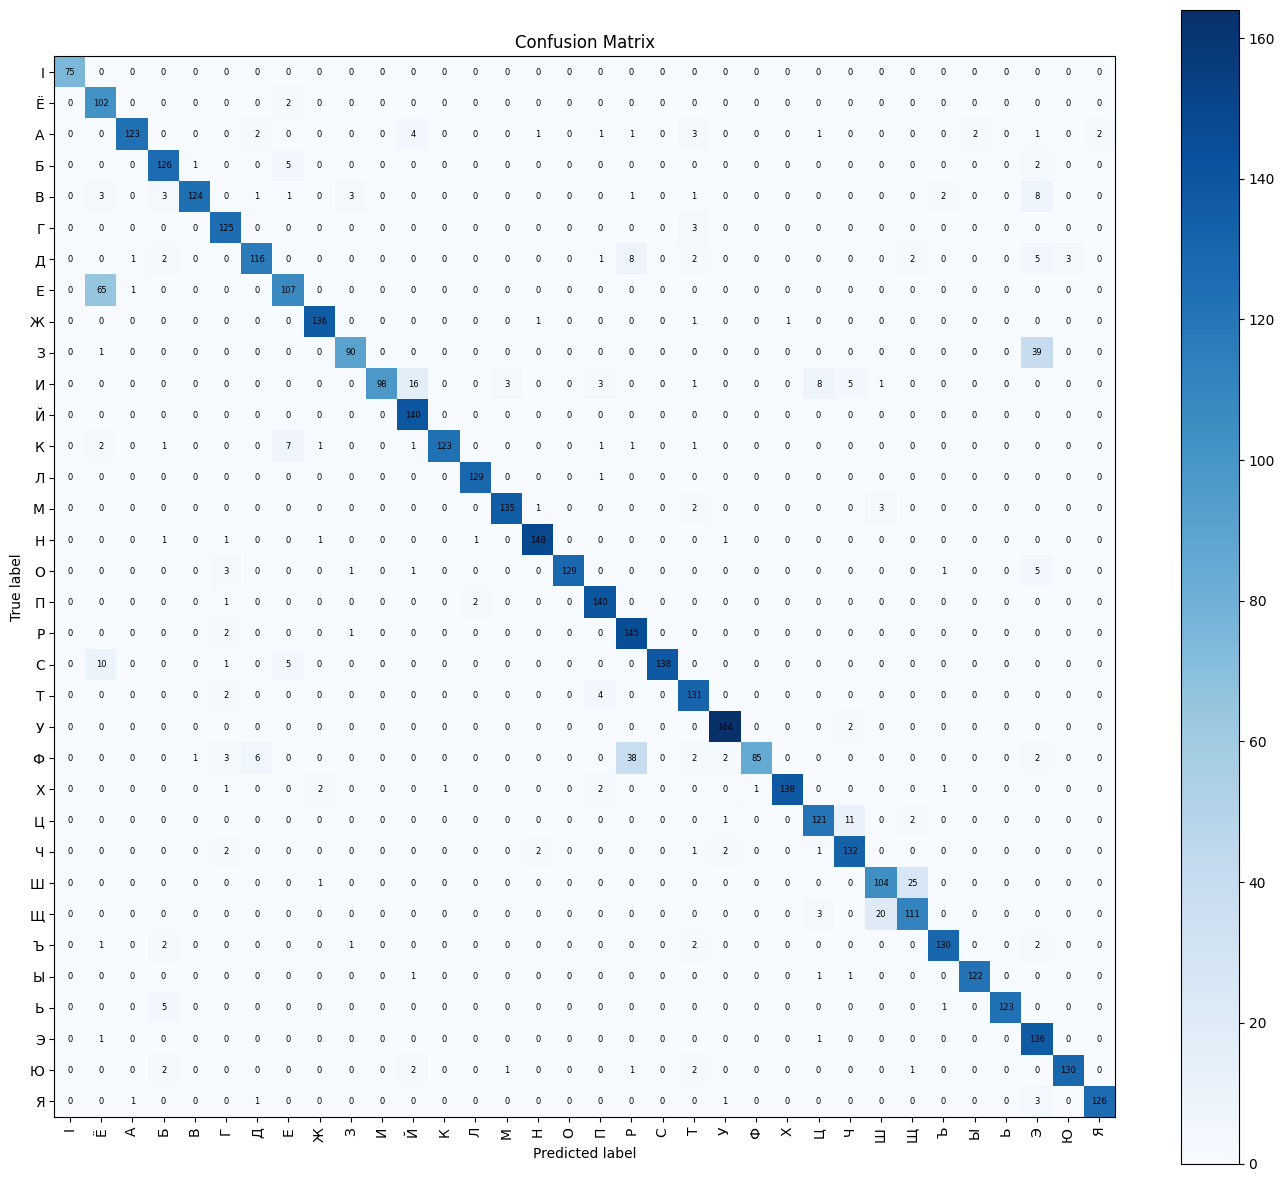

In [22]:
cm = confusion_matrix(y_true, y_pred)



plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=90)
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=6)
plt.tight_layout()
plt.show()